In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Load IB data
dfib = pd.read_csv("../IB_track_file/IBTrACS_TC_Size.csv",keep_default_na=False)
dfib['ISOTIME'] = pd.to_datetime(dfib['ISOTIME'])
dfib=dfib[((dfib.ISOTIME.dt.year.between(1988,2014) & (dfib.BASIN=='NA'))) | ((dfib.ISOTIME.dt.year.between(2002,2014)) & (dfib.BASIN=='WP'))].reset_index(drop=True)

Text(0.5, 1.0, 'Custom Colormap')

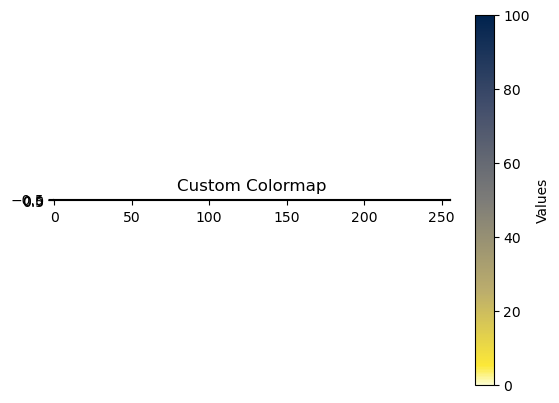

In [ ]:
# Define custom colormap
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pylab as pl
# cmap = pl.cm.cividis
# my_cmap = cmap(np.arange(cmap.N))
#my_cmap[255]

colors = [(0.99,0.99,0.80),(0.99, 0.91, 0.217772),(0.736488, 0.680629, 0.424028),(0.488697, 0.485318, 0.471008),(0.263738, 0.307831, 0.422789),(0,0.135112,0.304751,1)] 
positions = [0.0,0.05,0.25,0.5,0.75,1]  # Corresponding positions

# Create the custom colormap
new_spec = LinearSegmentedColormap.from_list('new_spec', list(zip(positions, colors)))

# Display the colormap
plt.imshow(np.linspace(0, 100, 256).reshape(1, -1), cmap=new_spec)
plt.colorbar(label='Values')
plt.title('Custom Colormap')

In [ ]:
# Load SyCLoPS data
files ={
    'mris': '../final_track_file/mris_SyCLoPS.csv',
    'mrih': '../final_track_file/mrih_SyCLoPS.csv',
    'ipslvhr': '../final_track_file/ipslvhr_SyCLoPS.csv',
    'ipslhr': '../final_track_file/ipslhr_SyCLoPS.csv',
    'echrm1': '../final_track_file/echrm1_SyCLoPS.csv',
    'eclrm1': '../final_track_file/eclrm1_SyCLoPS.csv',
    'era5deg1': '../final_track_file/era5deg1_SyCLoPS.csv',
    'era5': '../final_track_file/era5_SyCLoPS.csv',
    'hadgem': '../final_track_file/hadgem_SyCLoPS.csv',
    'cnrm': '../final_track_file/cnrm_SyCLoPS.csv',
    'hadgem-coup': '../final_track_file/hadgem-coup_SyCLoPS.csv',
    'cnrm-coup': '../final_track_file/cnrm-coup_SyCLoPS.csv',
    'echrm1-coup': '../final_track_file/echrm1-coup_SyCLoPS.csv',
    'ecearth3p': '../final_track_file/ecearth3p_SyCLoPS.csv'
}

dfpike = {}
for name, path in files.items():
    df = pd.read_csv(path,keep_default_na=False)
    dfpike[name] = df

In [ ]:
# Load ZU data
ZU_files = {
    'hadgemo': '../final_track_file/hadgem_ZU.csv',
    'cnrmo': '../final_track_file/cnrm_ZU.csv',
    'hadgem-coupo': '../final_track_file/hadgem-coup_ZU.csv',
    'cnrm-coupo': '../final_track_file/cnrm-coup_ZU.csv',
    'ecearth3po': '../final_track_file/ecearth3p_ZU.csv',
    'echrm1-coupo': '../final_track_file/echrm1-coup_ZU.csv',
    'era5o': '../final_track_file/era5_ZU.csv',
    'era5deg1o': '../final_track_file/era5deg1_ZU.csv',
    'mriso': '../final_track_file/mris_ZU.csv',
    'mriho': '../final_track_file/mrih_ZU.csv',
    'ipslvhro': '../final_track_file/ipslvhr_ZU.csv',
    'ipslhro': '../final_track_file/ipslhr_ZU.csv',
    'echrm1o': '../final_track_file/echrm1_ZU.csv',
    'eclrm1o': '../final_track_file/eclrm1_ZU.csv'
}

# Load and clean CSVs
dfo_tc = {}
for name, path in ZU_files.items():
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df = df.rename(columns={"lon": "LON", "lat": "LAT", "track_id": "TID"})
    if name =='era5o':
        df=df[df.year.between(1988, 2014)]
    dfo_tc[name] = df


In [6]:
# Figure 5 preparation
def myround20(number):
    return 20 * round(number / 20)

def myround5(number):
    return 5 * round(number / 5)
dfib_fig5=dfib[(dfib.MeanRad>0) & (dfib.MSLP>0)].copy()
dfib_fig5['MeanRadrd']=myround20(dfib_fig5['MeanRad'])
dfib_fig5['MSLPrd']=myround5(dfib_fig5['MSLP'])
totalct=len(dfib_fig5)
dfnc_ib=dfib_fig5.groupby(['MeanRadrd','MSLPrd'],as_index=True).agg({'LON':'count'}).unstack()
dfintlat_ib=dfib_fig5.groupby(['MSLPrd'])['LAT'].mean()
dfradlat_ib=dfib_fig5.groupby(['MeanRadrd'])['LAT'].mean()
dfnc_ib=dfnc_ib/totalct
dfnc_model={}
dfintlat_model={}
dfradlat_model={}
for name, df in dfpike.items():
    dft = df[(df.MeanRad > 0) & (((df.year.between(1988,2014) & (df.BASIN=='NA'))) | ((df.year.between(2002,2014) & (df.BASIN=='WP'))))].copy()
    totalct=len(dft)
    dft['MeanRadrd'] = myround20(dft['MeanRad'])
    dft['MSLPrd'] = myround5(dft['MSLP']/100)
    dfnc_model[name]=dft.groupby(['MeanRadrd','MSLPrd'],as_index=True).agg({'LON':'count'}).unstack()
    grouped_counts = dft.groupby(['MSLPrd'])['LAT'].count()
    grouped = dft.groupby(['MSLPrd'])['LAT'].mean()
    dfintlat_model[name] = grouped.where(grouped_counts >= 5, np.nan)
    grouped_counts = dft.groupby(['MeanRadrd'])['LAT'].count()
    grouped = dft.groupby(['MeanRadrd'])['LAT'].mean()
    dfradlat_model[name] = grouped.where(grouped_counts >= 5, np.nan)
    dfnc_model[name]=dfnc_model[name]/totalct
    
# Compute the mean across all models, aligning indices and columns
#dfnc_model['all_mean'] = pd.concat(dfnc_model.values()).groupby(level=0).mean()
dfnc_model['ib']=dfnc_ib
dfintlat_model['ib']=dfintlat_ib
dfradlat_model['ib']=dfradlat_ib
# Remove specified keys from the dictionary

# reorder the dictionary for plotting
dfn_keys_order = ['mris','ipslvhr','echrm1','echrm1-coup','hadgem','hadgem-coup','ecearth3p','cnrm','cnrm-coup','ipslhr','eclrm1','mrih','era5','era5deg1','ib']
dfnc_model = {k: dfnc_model[k] for k in dfn_keys_order if k in dfnc_model}
dfintlat_model = {k: dfintlat_model[k] for k in dfn_keys_order if k in dfintlat_model}
dfradlat_model = {k: dfradlat_model[k] for k in dfn_keys_order if k in dfradlat_model}
# change names of keys for plotting

/tmp/ipykernel_1000680/1858811238.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


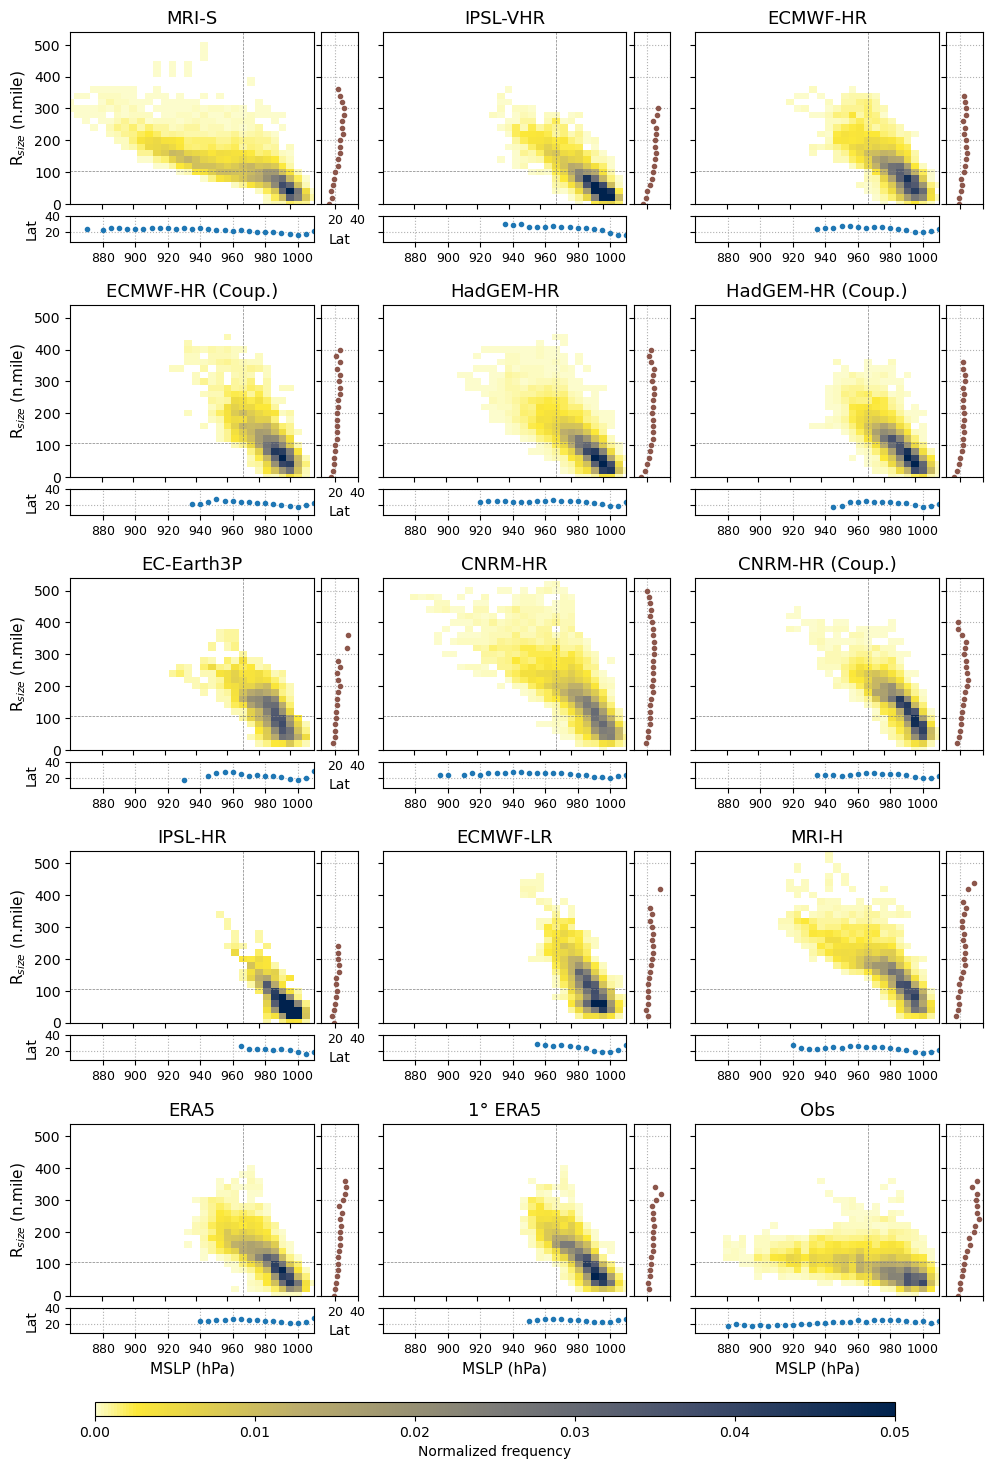

In [ ]:
labels = ['ERA5','1° ERA5','HR mean','LR mean','Obs']
colors = ['grey','grey','tab:orange','tab:orange','k']

model_title = ['MRI-S','IPSL-VHR','ECMWF-HR','ECMWF-HR (Coup.)','HadGEM-HR','HadGEM-HR (Coup.)','EC-Earth3P','CNRM-HR','CNRM-HR (Coup.)','IPSL-HR','ECMWF-LR','MRI-H','ERA5','1° ERA5','Obs']

#Plotting Figure 7
model_keys = list(dfnc_model.keys())
fig = plt.figure(figsize=(10, 14))
#nrows, ncols = 3, 3
#gs = fig.add_gridspec(nrows,ncols,height_ratios=[1,1,1,1.8],width_ratios=[1,1,1])
levels=[10,20,30,40]
for idx, key in enumerate(model_keys):
    ax = fig.add_subplot(5,3,idx+1)
    #ax = axes[idx // ncols, idx % ncols]
    data = dfnc_model[key]
    # Get the grid for plotting
    y = data.index.values  # MeanRadrd (y-axis)
    x = data.columns.levels[1].values  # WSrd (x-axis)
    X, Y = np.meshgrid(x, y)
    Z = data.values
    pcm = ax.pcolormesh(X, Y, Z, shading='auto', cmap=new_spec, vmin=0, vmax=0.05)
    # Plot embedded mean latitude vs MSLPrd below x-axis
    inset_ax_x = ax.inset_axes([0, -0.22, 1, 0.15])
    inset_ax_x.plot(dfintlat_model[key].index, dfintlat_model[key].values, color='tab:blue', marker='o', lw=0, ms=3)
    if idx in [0,3,6,9,12]:
        inset_ax_x.set_ylabel('Lat', fontsize=10)
    else:
        inset_ax_x.set_yticklabels([])
    inset_ax_x.set_xlabel('')
    inset_ax_x.tick_params(axis='both', which='major', labelsize=9)
    inset_ax_x.set_xlim(860,1010)
    inset_ax_x.set_ylim(8, 40)
    inset_ax_x.grid(True, linestyle=':')
    inset_ax_x.set_xticks(np.arange(880, 1020, 20))
    ax.set_xticks(np.arange(880, 1020, 20))
    ax.set_xticklabels([])
    if idx in [12, 13, 14]:
        inset_ax_x.set_xlabel('MSLP (hPa)', fontsize=11)
    # Plot embedded mean latitude vs MeanRadrd to the right of y-axis
    
    inset_ax_y = ax.inset_axes([1.03, 0, 0.15, 1])
    inset_ax_y.plot(dfradlat_model[key].values, dfradlat_model[key].index, color='tab:brown', marker='o', lw=0, ms=3)
    inset_ax_y.set_ylabel('')
    inset_ax_y.tick_params(axis='both', which='major', labelsize=9)
    inset_ax_y.set_ylim(0,540)
    inset_ax_y.set_xlim(8, 40)
    inset_ax_y.set_yticks(np.arange(0, 600, 100))
    inset_ax_y.grid(True, linestyle=':')
    inset_ax_y.set_yticklabels([])
    if idx in [0,3,6,9,12]:
        inset_ax_y.set_xlabel('Lat', fontsize=10)
    else:
        inset_ax_y.set_xticklabels([])
    ax.set_title(model_title[idx], fontsize=13)
    ax.set_yticklabels([])
    if idx in [0, 3, 6, 9, 12]:
        ax.set_ylabel('R$_{size}$ (n.mile)',fontsize=11)
        ax.set_yticks(np.arange(0, 600, 100))
        ax.set_yticklabels(labels=np.arange(0, 600, 100), fontsize=10)
    # if idx in [12, 13, 14]:
    #     ax.set_xlabel('MSLP (hPa)',fontsize=10)
    ax.set_xlim(860, 1015)
    ax.set_ylim(0, 540)
    ax.axvline(x=970, color='gray', linestyle='--', lw=0.5)
    ax.axhline(y=105, color='gray', linestyle='--', lw=0.5)


# Add a single vertical colorbar at the right of the first three rows
cbar_ax = fig.add_axes([0.1, -0.015, 0.8, 0.01])  # [left, bottom, width, height]
fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', label='Normalized frequency')
plt.tight_layout()
fig.savefig('../figures/size/figure7_2.jpg', dpi=350, bbox_inches='tight')
